# USD/CAD method comparison analysis

This notebook analyzes the cached results produced by `01_usdcad_multivariate_backtest.ipynb`. It answers three questions:

1. Which model performed best at each forecast horizon?
2. Do covariates improve the target-only models, and where?
3. Which registered USD/CAD covariates are most associated with each forward-return target?

The notebook is analysis-only: it reads saved backtest artifacts and does not run missing forecasts. A missing cache is reported as unavailable rather than computed. CRPS is the primary ranking metric (lower is better); directional accuracy, F1, and ROC AUC are secondary views.

## Interpretation guardrails

The covariate section has two distinct kinds of evidence. Paired target-only versus covariate-aware model deltas measure whether adding the full panel helped a model family. The correlation section is a lagged Spearman association diagnostic between an available covariate and a realized forward return. It is not causal feature importance, and it does not prove that a model used a covariate effectively.

The LLM rows are included only when their post-cutoff cache artifacts exist. The `stress_2020` window should be interpreted as numerical-only because the LLM would be pre-cutoff.

In [16]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from dotenv import load_dotenv

def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'aieng-forecasting').is_dir():
            return candidate
    return here

ROOT = _repo_root()
IMPLEMENTATIONS = ROOT / 'implementations'
if str(IMPLEMENTATIONS) not in sys.path:
    sys.path.insert(0, str(IMPLEMENTATIONS))
load_dotenv(ROOT / '.env', override=False)

from aieng.forecasting.evaluation import MultiTargetBacktestSpec
from aieng.forecasting.evaluation.artifacts import load_multi_backtest_results
from usdcad_forecasting import DEFAULT_COVARIATE_SERIES_IDS, build_usdcad_multivariate_service
from usdcad_forecasting.leaderboard import build_leaderboard
from usdcad_forecasting.analysis import style_results_dataframe
from aieng.forecasting.methods import (
    DartsAutoARIMAPredictor, DartsExponentialSmoothingPredictor,
    DartsKalmanForecasterPredictor, DartsLightGBMPredictor,
    DartsLinearRegressionPredictor, LastValuePredictor,
)
from usdcad_forecasting.predictors import build_usdcad_llmp_sampled_trajectory

EXPERIMENT_CONFIG = 'smoke'  # change to 'backtest_2025' when those artifacts exist
SPEC_FILES = {
    'smoke': 'usdcad_smoke.yaml',
    'backtest_2025': 'usdcad_backtest_2025.yaml',
    'stress_2020': 'usdcad_stress_2020.yaml',
}
SPECS_DIR = ROOT / 'implementations' / 'usdcad_forecasting' / 'specs'
STORE_DIR = ROOT / 'data' / 'predictions'
DATA_HISTORY_START = '2016-01-01'

In [17]:
with (SPECS_DIR / SPEC_FILES[EXPERIMENT_CONFIG]).open() as handle:
    backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(handle))

svc = build_usdcad_multivariate_service(
    windows=(1, 5, 21),
    include_covariates=True,
    covariate_series_ids=DEFAULT_COVARIATE_SERIES_IDS,
    start=DATA_HISTORY_START,
    refresh=False,
)
registered = set(svc.series_ids)
COVARIATES = [series_id for series_id in DEFAULT_COVARIATE_SERIES_IDS if series_id in registered]
print(f'Analysis window: {EXPERIMENT_CONFIG}')
print(f'Registered covariates: {len(COVARIATES)} / {len(DEFAULT_COVARIATE_SERIES_IDS)}')
print(COVARIATES)

Analysis window: smoke
Registered covariates: 8 / 8
['usdcad_log_ret_1b_l1b', 'fed_funds_level_l1b', 'ust2y_level_l1b', 'ust10y_level_l1b', 'ust2y10y_spread_l1b', 'cpi_mom_logdiff_l1b', 'unemployment_rate_l1b', 'oil_log_ret_1b_l1b']


## Recreate the backtest roster

These predictor IDs and labels mirror the original notebook. The objects are used only to identify the corresponding cache files; no forecast method is called.

In [5]:
LAGS = 5
NUM_SAMPLES = 100
LGBM_KWARGS = {'num_threads': 1, 'n_jobs': 1, 'verbosity': -1}

naive = LastValuePredictor()
ets = DartsExponentialSmoothingPredictor(num_samples=NUM_SAMPLES)
kalman = DartsKalmanForecasterPredictor(num_samples=NUM_SAMPLES)
autoarima = DartsAutoARIMAPredictor(num_samples=NUM_SAMPLES)
linreg = DartsLinearRegressionPredictor(lags=LAGS, covariate_series_ids=None, num_samples=NUM_SAMPLES)
linreg_cov = DartsLinearRegressionPredictor(lags=LAGS, lags_past_covariates=LAGS, covariate_series_ids=COVARIATES, num_samples=NUM_SAMPLES)
lightgbm = DartsLightGBMPredictor(lags=LAGS, covariate_series_ids=None, num_samples=NUM_SAMPLES, lgbm_kwargs=LGBM_KWARGS)
lightgbm_cov = DartsLightGBMPredictor(lags=LAGS, lags_past_covariates=LAGS, covariate_series_ids=COVARIATES, num_samples=NUM_SAMPLES, lgbm_kwargs=LGBM_KWARGS)

predictor_specs = [
    (naive, 'Naive', []), (ets, 'ETS', []), (kalman, 'Kalman', []),
    (autoarima, 'AutoARIMA', []), (linreg, 'LinReg', []),
    (linreg_cov, 'LinReg + cov', COVARIATES),
    (lightgbm, 'LightGBM', []), (lightgbm_cov, 'LightGBM + cov', COVARIATES),
]
if EXPERIMENT_CONFIG != 'stress_2020':
    llmp = build_usdcad_llmp_sampled_trajectory(n_samples=8, history_window=48)
    llmp_cov = build_usdcad_llmp_sampled_trajectory(n_samples=8, history_window=48, covariate_series_ids=COVARIATES)
    predictor_specs += [(llmp, 'LLMP (target)', []), (llmp_cov, 'LLMP + cov', COVARIATES)]

labels = {predictor.predictor_id: label for predictor, label, _ in predictor_specs}
covariates_by_predictor = {predictor.predictor_id: covs for predictor, _, covs in predictor_specs}
print(pd.DataFrame([(p.predictor_id, label, len(covs)) for p, label, covs in predictor_specs], columns=['predictor_id', 'model', 'n_covariates']))

                                        predictor_id           model  \
0                                   last_value_naive           Naive   
1                                          darts_ets             ETS   
2                                       darts_kalman          Kalman   
3                                    darts_autoarima       AutoARIMA   
4                                       darts_linreg          LinReg   
5                                   darts_linreg_cov    LinReg + cov   
6                                     darts_lightgbm        LightGBM   
7                                 darts_lightgbm_cov  LightGBM + cov   
8  llmp_sampled_trajectories_usdcad_v1_target_h48...   LLMP (target)   
9  llmp_sampled_trajectories_usdcad_v1_cov_h48_n8...      LLMP + cov   

   n_covariates  
0             0  
1             0  
2             0  
3             0  
4             0  
5             8  
6             0  
7             8  
8             0  
9             8  


In [18]:
def load_cached_results(predictor_specs, spec, store_dir):
    loaded = {}
    missing = []
    for predictor, label, _ in predictor_specs:
        task_results = load_multi_backtest_results(spec, predictor.predictor_id, store_dir=store_dir)
        if task_results is None:
            missing.append(label)
        else:
            loaded[predictor.predictor_id] = task_results
    return loaded, missing

cached_results, missing_cache = load_cached_results(predictor_specs, backtest_spec, STORE_DIR)
PREDICTOR_LABELS = labels
RESULTS_DF = build_leaderboard(cached_results, svc, covariates_by_predictor=covariates_by_predictor, labels_by_predictor=PREDICTOR_LABELS)
print(f'Loaded {len(RESULTS_DF)} leaderboard rows from cache.')
if missing_cache:
    print(f'Missing complete cached predictor results: {len(missing_cache)}. No forecasts were run.')
    print(missing_cache)
display(style_results_dataframe(RESULTS_DF))

Loaded 30 leaderboard rows from cache.


,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval
0,1,usdcad_logret_1b,LightGBM + cov,True,8,"usdcad_log_ret_1b_l1b, fed_funds_level_l1b, ust2y_level_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b",darts_lightgbm_cov,0.00125,5,5,1,0.400,1.000,0.571,0.400,0.333,5
1,1,usdcad_logret_1b,LinReg,False,0,—,darts_linreg,0.00136,5,5,1,0.500,0.500,0.500,0.600,0.500,5
2,1,usdcad_logret_1b,LightGBM,False,0,—,darts_lightgbm,0.00138,5,5,1,0.333,0.500,0.400,0.400,0.333,5
3,1,usdcad_logret_1b,LinReg + cov,True,8,"usdcad_log_ret_1b_l1b, fed_funds_level_l1b, ust2y_level_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b",darts_linreg_cov,0.00139,5,5,1,0.500,0.500,0.500,0.600,0.500,5
4,1,usdcad_logret_1b,AutoARIMA,False,0,—,darts_autoarima,0.00142,5,5,1,1.000,0.500,0.667,0.800,1.000,5
5,1,usdcad_logret_1b,ETS,False,0,—,darts_ets,0.00143,5,5,1,0.500,0.500,0.500,0.600,0.500,5
6,1,usdcad_logret_1b,Kalman,False,0,—,darts_kalman,0.00146,5,5,1,0.333,0.500,0.400,0.400,0.667,5
7,1,usdcad_logret_1b,Naive,False,0,—,last_value_naive,0.00158,5,5,1,0.500,0.500,0.500,0.600,0.583,5
8,1,usdcad_logret_1b,LLMP (target),False,0,—,llmp_sampled_trajectories_usdcad_v1_target_h48_n8[gemini-3.1-flash-lite-preview],0.00164,5,5,1,0.000,0.000,0.000,0.600,0.500,5
9,1,usdcad_logret_1b,LLMP + cov,True,8,"usdcad_log_ret_1b_l1b, fed_funds_level_l1b, ust2y_level_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b",llmp_sampled_trajectories_usdcad_v1_cov_h48_n8[gemini-3.1-flash-lite-preview],0.00165,5,5,1,0.000,0.000,0.000,0.400,0.333,5


## 1. Best model by horizon

The primary winner is the lowest mean CRPS among available cached rows. Directional metrics are shown alongside it because a probabilistic forecast can rank differently on distributional accuracy and sign prediction.

In [ ]:
ranking = RESULTS_DF.sort_values(['horizon', 'mean_crps', 'model']).copy()
ranking['rank'] = ranking.groupby('horizon')['mean_crps'].rank(method='min')
best_by_horizon = ranking[ranking['rank'].eq(1)].copy()
best_by_horizon[['horizon', 'model', 'mean_crps', 'dir_accuracy', 'dir_f1_up', 'dir_roc_auc_prob_up', 'n_predictions']]

,horizon,model,mean_crps,dir_accuracy,dir_f1_up,dir_roc_auc_prob_up,n_predictions
0,1,LightGBM + cov,0.001248,0.4,0.571429,0.333333,5
1,5,LightGBM + cov,0.002254,0.4,0.571429,0.500000,5
2,21,LightGBM + cov,0.010010,0.8,0.000000,0.750000,5


## All methods by horizon

The backtest roster is broader than the covariate-pair analysis: Naive, ETS, Kalman, AutoARIMA, Linear Regression, LightGBM, and both LLMP variants are all included when their cached results are available. The table below preserves the full ranking for every horizon. The covariate-impact section below is narrower because only Linear Regression, LightGBM, and LLMP were run in both target-only and covariate-aware forms; the classical and Naive methods were intentionally univariate.

In [19]:
all_method_ranking = (
    RESULTS_DF
    .sort_values(['horizon', 'mean_crps', 'model'])
    .assign(rank=lambda frame: frame.groupby('horizon')['mean_crps'].rank(method='min'))
)

all_method_ranking[
    [
        'horizon', 'rank', 'model', 'mean_crps',
        'dir_accuracy', 'dir_f1_up', 'dir_roc_auc_prob_up',
        'uses_covariates', 'n_predictions',
    ]
]

,horizon,rank,model,mean_crps,dir_accuracy,dir_f1_up,dir_roc_auc_prob_up,uses_covariates,n_predictions
0,1,1.0,LightGBM + cov,0.001248,0.4,0.571429,0.333333,True,5
1,1,2.0,LinReg,0.001357,0.6,0.500000,0.500000,False,5
2,1,3.0,LightGBM,0.001384,0.4,0.400000,0.333333,False,5
3,1,4.0,LinReg + cov,0.001388,0.6,0.500000,0.500000,True,5
4,1,5.0,AutoARIMA,0.001424,0.8,0.666667,1.000000,False,5
5,1,6.0,ETS,0.001429,0.6,0.500000,0.500000,False,5
6,1,7.0,Kalman,0.001455,0.4,0.400000,0.666667,False,5
7,1,8.0,Naive,0.001577,0.6,0.500000,0.583333,False,5
8,1,9.0,LLMP (target),0.001644,0.6,0.000000,0.500000,False,5
9,1,10.0,LLMP + cov,0.001650,0.4,0.000000,0.333333,True,5


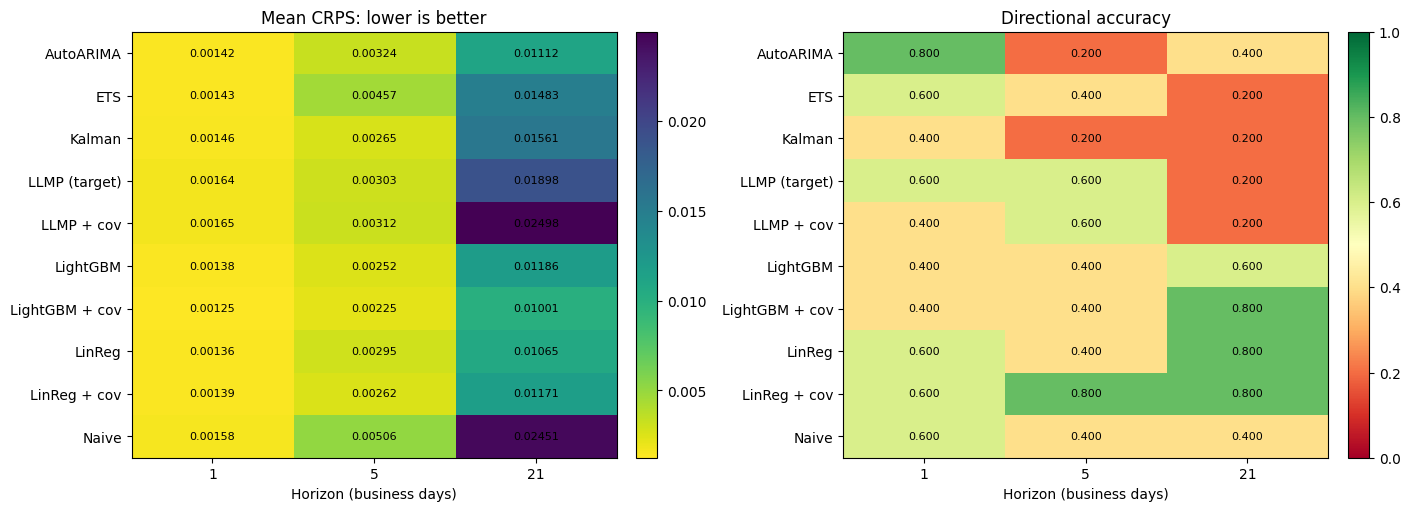

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
crps_pivot = RESULTS_DF.pivot_table(index='model', columns='horizon', values='mean_crps', aggfunc='mean')
crps_image = axes[0].imshow(crps_pivot.to_numpy(dtype=float), aspect='auto', cmap='viridis_r')
axes[0].set_xticks(range(len(crps_pivot.columns)), crps_pivot.columns)
axes[0].set_yticks(range(len(crps_pivot.index)), crps_pivot.index)
axes[0].set_title('Mean CRPS: lower is better')
axes[0].set_xlabel('Horizon (business days)')
for row in range(crps_pivot.shape[0]):
    for column in range(crps_pivot.shape[1]):
        value = crps_pivot.iloc[row, column]
        if pd.notna(value):
            axes[0].text(column, row, f'{value:.5f}', ha='center', va='center', fontsize=8)
fig.colorbar(crps_image, ax=axes[0], fraction=0.046, pad=0.04)

direction_pivot = RESULTS_DF.pivot_table(index='model', columns='horizon', values='dir_accuracy', aggfunc='mean')
direction_image = axes[1].imshow(direction_pivot.to_numpy(dtype=float), aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_xticks(range(len(direction_pivot.columns)), direction_pivot.columns)
axes[1].set_yticks(range(len(direction_pivot.index)), direction_pivot.index)
axes[1].set_title('Directional accuracy')
axes[1].set_xlabel('Horizon (business days)')
for row in range(direction_pivot.shape[0]):
    for column in range(direction_pivot.shape[1]):
        value = direction_pivot.iloc[row, column]
        if pd.notna(value):
            axes[1].text(column, row, f'{value:.3f}', ha='center', va='center', fontsize=8)
fig.colorbar(direction_image, ax=axes[1], fraction=0.046, pad=0.04)
plt.show()

## 2. What did the covariates add?

This section is intentionally a paired comparison, not the complete model roster. Naive, ETS, Kalman, and AutoARIMA were run as univariate methods, so there is no covariate version of those models in the backtest. For Linear Regression, LightGBM, and LLMP, `delta_crps = target-only CRPS - covariate CRPS`; positive values mean the covariate version improved CRPS. The same convention is used for directional accuracy and F1, where positive values mean improvement.

In [22]:
def paired_delta(frame, target_model, cov_model, family):
    left = frame[frame['model'].eq(target_model)][['horizon', 'mean_crps', 'dir_accuracy', 'dir_f1_up']].rename(columns={'mean_crps': 'crps_target', 'dir_accuracy': 'accuracy_target', 'dir_f1_up': 'f1_target'})
    right = frame[frame['model'].eq(cov_model)][['horizon', 'mean_crps', 'dir_accuracy', 'dir_f1_up']].rename(columns={'mean_crps': 'crps_cov', 'dir_accuracy': 'accuracy_cov', 'dir_f1_up': 'f1_cov'})
    out = left.merge(right, on='horizon', how='inner')
    out['family'] = family
    out['delta_crps_target_minus_cov'] = out['crps_target'] - out['crps_cov']
    out['delta_accuracy_cov_minus_target'] = out['accuracy_cov'] - out['accuracy_target']
    out['delta_f1_cov_minus_target'] = out['f1_cov'] - out['f1_target']
    return out

pair_deltas = pd.concat([
    paired_delta(RESULTS_DF, 'LinReg', 'LinReg + cov', 'Linear Regression'),
    paired_delta(RESULTS_DF, 'LightGBM', 'LightGBM + cov', 'LightGBM'),
    paired_delta(RESULTS_DF, 'LLMP (target)', 'LLMP + cov', 'LLM-Process'),
], ignore_index=True)
display(pair_deltas.sort_values(['family', 'horizon']))

,horizon,crps_target,accuracy_target,f1_target,crps_cov,accuracy_cov,f1_cov,family,delta_crps_target_minus_cov,delta_accuracy_cov_minus_target,delta_f1_cov_minus_target
6,1,0.001644,0.6,0.000000,0.001650,0.4,0.000000,LLM-Process,-0.000006,-0.2,0.000000
7,5,0.003031,0.6,0.000000,0.003118,0.6,0.000000,LLM-Process,-0.000087,0.0,0.000000
8,21,0.018976,0.2,0.000000,0.024981,0.2,0.333333,LLM-Process,-0.006005,0.0,0.333333
3,1,0.001384,0.4,0.400000,0.001248,0.4,0.571429,LightGBM,0.000137,0.0,0.171429
4,5,0.002520,0.4,0.400000,0.002254,0.4,0.571429,LightGBM,0.000266,0.0,0.171429
5,21,0.011863,0.6,0.000000,0.010010,0.8,0.000000,LightGBM,0.001853,0.2,0.000000
0,1,0.001357,0.6,0.500000,0.001388,0.6,0.500000,Linear Regression,-0.000031,0.0,0.000000
1,5,0.002946,0.4,0.571429,0.002619,0.8,0.800000,Linear Regression,0.000328,0.4,0.228571
2,21,0.010649,0.8,0.000000,0.011708,0.8,0.666667,Linear Regression,-0.001060,0.0,0.666667


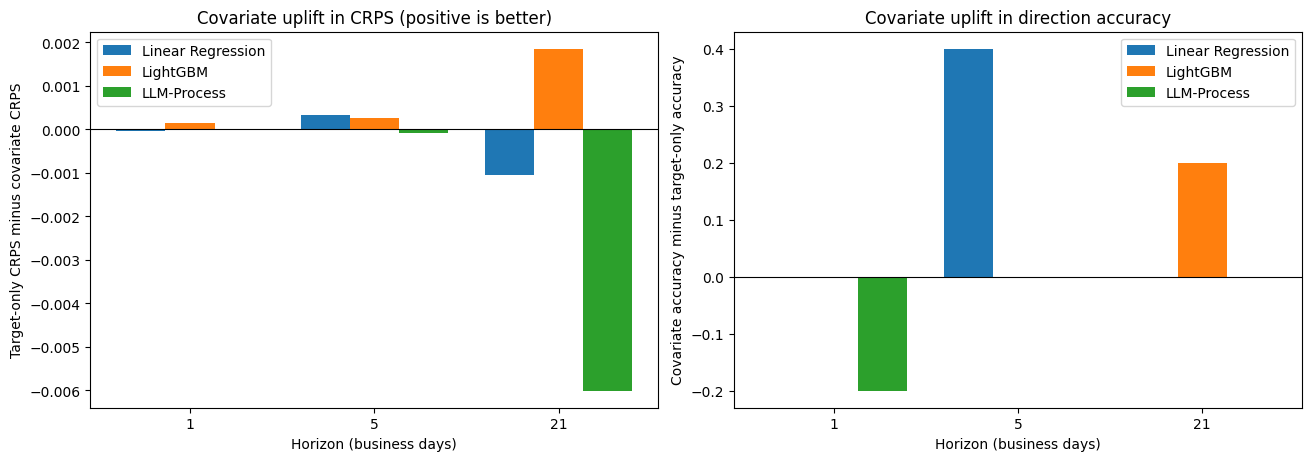

In [23]:
if not pair_deltas.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    families = list(pair_deltas['family'].drop_duplicates())
    horizons = sorted(pair_deltas['horizon'].unique())
    x = np.arange(len(horizons))
    width = 0.8 / max(len(families), 1)
    for position, family in enumerate(families):
        group = pair_deltas[pair_deltas['family'].eq(family)].set_index('horizon').reindex(horizons)
        offset = (position - (len(families) - 1) / 2) * width
        axes[0].bar(x + offset, group['delta_crps_target_minus_cov'], width, label=family)
        axes[1].bar(x + offset, group['delta_accuracy_cov_minus_target'], width, label=family)
    for axis in axes:
        axis.axhline(0, color='black', linewidth=0.8)
        axis.set_xticks(x, horizons)
        axis.set_xlabel('Horizon (business days)')
        axis.legend()
    axes[0].set_title('Covariate uplift in CRPS (positive is better)')
    axes[0].set_ylabel('Target-only CRPS minus covariate CRPS')
    axes[1].set_title('Covariate uplift in direction accuracy')
    axes[1].set_ylabel('Covariate accuracy minus target-only accuracy')
    plt.show()
else:
    print('No complete target-only/covariate pairs are available in this cache.')

## 3. Covariate association diagnostics

For each forecast origin, this section aligns the one-business-day-lagged covariate history with the realized forward-return target and computes Spearman correlation. The strongest absolute values identify where a covariate and horizon move together in this sample. They are association diagnostics, not causal importance scores or proof of model reliance.

In [25]:
from datetime import datetime, timezone


def correlation_table(data_service, covariates, spec):
    rows = []
    as_of_now = datetime.now(tz=timezone.utc).replace(tzinfo=None)
    for single_spec in spec.specs():
        target_id = single_spec.task.target_series_id
        target = data_service.get_series(target_id, as_of=as_of_now).copy()
        target['timestamp'] = pd.to_datetime(target['timestamp'])
        target = target.set_index('timestamp')['value'].rename('target')
        for covariate_id in covariates:
            cov = data_service.get_series(covariate_id, as_of=as_of_now).copy()
            cov['timestamp'] = pd.to_datetime(cov['timestamp'])
            cov = cov.set_index('timestamp')['value'].rename('covariate')
            aligned = pd.concat([cov, target], axis=1, sort=False).dropna()
            if len(aligned) < 8:
                continue
            spearman_r = aligned['covariate'].corr(aligned['target'], method='spearman')
            rows.append({
                'horizon': int(max(single_spec.task.horizons)),
                'target': target_id,
                'covariate': covariate_id,
                'spearman_r': spearman_r,
                'abs_spearman_r': abs(spearman_r),
                'n_overlap': len(aligned),
            })
    return pd.DataFrame(rows)


CORR_DF = correlation_table(svc, COVARIATES, backtest_spec)
display(CORR_DF.sort_values(['horizon', 'abs_spearman_r'], ascending=[True, False]))

,horizon,target,covariate,spearman_r,abs_spearman_r,n_overlap
6,1,usdcad_logret_1b,unemployment_rate_l1b,-0.034717,0.034717,2665
2,1,usdcad_logret_1b,ust2y_level_l1b,0.032155,0.032155,2676
3,1,usdcad_logret_1b,ust10y_level_l1b,0.030746,0.030746,2676
5,1,usdcad_logret_1b,cpi_mom_logdiff_l1b,0.029047,0.029047,2665
1,1,usdcad_logret_1b,fed_funds_level_l1b,0.026013,0.026013,2676
4,1,usdcad_logret_1b,ust2y10y_spread_l1b,-0.022897,0.022897,2676
7,1,usdcad_logret_1b,oil_log_ret_1b_l1b,0.019025,0.019025,2674
0,1,usdcad_logret_1b,usdcad_log_ret_1b_l1b,-0.010493,0.010493,2676
14,5,usdcad_logret_5b,unemployment_rate_l1b,-0.093365,0.093365,2663
13,5,usdcad_logret_5b,cpi_mom_logdiff_l1b,0.089335,0.089335,2663


Top absolute associations by horizon:


,horizon,target,covariate,spearman_r,abs_spearman_r,n_overlap
6,1,usdcad_logret_1b,unemployment_rate_l1b,-0.034717,0.034717,2665
2,1,usdcad_logret_1b,ust2y_level_l1b,0.032155,0.032155,2676
3,1,usdcad_logret_1b,ust10y_level_l1b,0.030746,0.030746,2676
5,1,usdcad_logret_1b,cpi_mom_logdiff_l1b,0.029047,0.029047,2665
1,1,usdcad_logret_1b,fed_funds_level_l1b,0.026013,0.026013,2676
14,5,usdcad_logret_5b,unemployment_rate_l1b,-0.093365,0.093365,2663
13,5,usdcad_logret_5b,cpi_mom_logdiff_l1b,0.089335,0.089335,2663
10,5,usdcad_logret_5b,ust2y_level_l1b,0.070095,0.070095,2672
12,5,usdcad_logret_5b,ust2y10y_spread_l1b,-0.065562,0.065562,2672
9,5,usdcad_logret_5b,fed_funds_level_l1b,0.062750,0.062750,2672


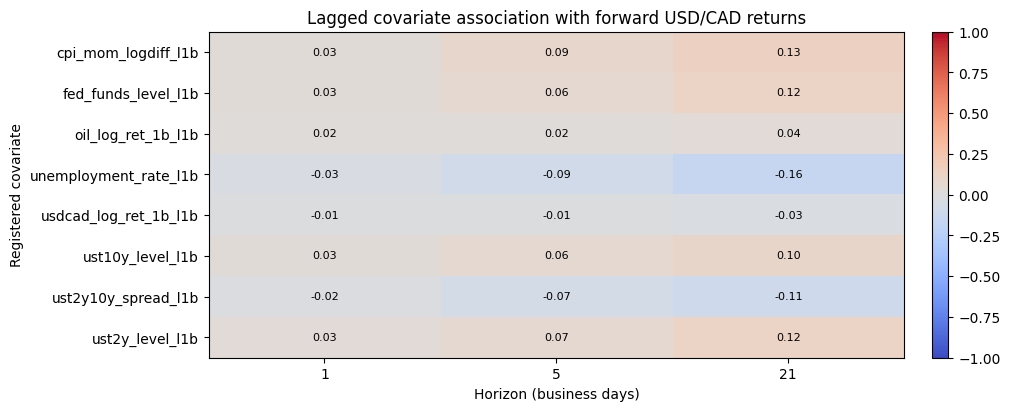

In [14]:
if not CORR_DF.empty:
    corr_pivot = CORR_DF.pivot(index='covariate', columns='horizon', values='spearman_r')
    fig, axis = plt.subplots(figsize=(10, max(4, 0.45 * len(corr_pivot))), constrained_layout=True)
    image = axis.imshow(corr_pivot.to_numpy(dtype=float), aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    axis.set_xticks(range(len(corr_pivot.columns)), corr_pivot.columns)
    axis.set_yticks(range(len(corr_pivot.index)), corr_pivot.index)
    axis.set_title('Lagged covariate association with forward USD/CAD returns')
    axis.set_xlabel('Horizon (business days)')
    axis.set_ylabel('Registered covariate')
    for row in range(corr_pivot.shape[0]):
        for column in range(corr_pivot.shape[1]):
            value = corr_pivot.iloc[row, column]
            if pd.notna(value):
                axis.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8)
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    print('Top absolute associations by horizon:')
    display(CORR_DF.sort_values(['horizon', 'abs_spearman_r'], ascending=[True, False]).groupby('horizon').head(5))
    plt.show()
else:
    print('No covariate/target overlaps were available for the selected window.')

## Reading the result

Use the horizon winner table for the direct answer. Use paired deltas to decide whether the full covariate panel helped a model family at a specific horizon. Use the association table to identify economically interesting signals, but keep the distinction clear: a high correlation can be unstable, redundant with another covariate, or absent from the best model's learned decision rule.